# RAG Orchestrator — Movie & TV Plot QA

1. Classifier + Rewrite Agent

Replaces what would have been two separate calls. Single LLM call that simultaneously labels the question as factual/emotional/vague AND rewrites it into a HyDE query for vector search.

2. Title Filter Agent

After generation, makes an LLM call to resolve which specific show or movie the question is about by examining the retrieved chunks. Filters chunks to only those matching the resolved title. If too few match, signals the graph to trigger re-retrieval.


3. Critic Agent

Fact-checks the generated answer against the retrieved chunks. If unsupported, rewrites a corrected answer within the evidence. After 2 failed retries routes to Not Found.

## 1. Imports

In [1]:
import os
import json
import time
from dataclasses import dataclass
from enum import Enum
from typing import Any, Dict, List, Optional, TypedDict
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.spatial.distance as spdist
from tqdm import tqdm
from dotenv import load_dotenv
from pinecone import Pinecone

from langsmith import Client
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.retrievers import BaseRetriever
from langchain_core.runnables import (
    RunnableLambda,
    RunnableParallel,
    RunnablePassthrough,
)
from langchain_core.runnables.graph import MermaidDrawMethod
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from operator import itemgetter

from sentence_transformers import CrossEncoder

from langgraph.graph import END, StateGraph

from IPython.display import Image, display

/Users/amily/Desktop/stitching-project-evelynh037/genai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.




## 2. Utilities

### 2a. Environment & API Keys

In [2]:
load_dotenv()

OPENAI_API_KEY   = os.getenv("OPENAI_API_KEY")
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError(
        "OPENAI_API_KEY not found in environment variables.\n"
        "Please create a .env file in the project root with:\n"
        "OPENAI_API_KEY=your_openai_api_key_here"
    )
if not PINECONE_API_KEY:
    raise ValueError(
        "PINECONE_API_KEY not found in environment variables.\n"
        "Please create a .env file in the project root with:\n"
        "PINECONE_API_KEY=your_pinecone_api_key_here"
    )

os.environ["OPENAI_API_KEY"]   = OPENAI_API_KEY
os.environ["PINECONE_API_KEY"] = PINECONE_API_KEY

print("\u2713 API keys loaded successfully")

✓ API keys loaded successfully


### 2b. Vector Store & Raw Data

In [3]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2"
)

PINECONE_INDEX = "stream-embeddings"
TEXT_FIELD     = "id"

vectorstore = PineconeVectorStore(
    index_name=PINECONE_INDEX,
    embedding=embeddings,
    text_key=TEXT_FIELD,
    pinecone_api_key=PINECONE_API_KEY,
)
time.sleep(10)
print("\u2713 Vector store initialised")

/var/folders/bf/mf9fw9915q98qdc0k4pv6gnr0000gn/T/ipykernel_26300/599984208.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
/Users/amily/Desktop/stitching-project-evelynh037/genai/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


✓ Vector store initialised


In [4]:
with open("chunk_data/merged_chunks.json", "r", encoding="utf-8") as f:
    data = json.load(f)

raw_text: Dict[str, str] = {item["id"]: item["text"] for item in data}
print(f"\u2713 Loaded {len(raw_text):,} raw chunks")

✓ Loaded 7,898 raw chunks


### 2c. LLM, Retriever & Prompt

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", seed=0)

class CustomRetriever(BaseRetriever):
    """Wraps PineconeVectorStore and swaps in the original raw text per chunk."""
    vectorstore: PineconeVectorStore
    splits: Dict[str, str]

    def _get_relevant_documents(self, query: str) -> list[Document]:
        docs = self.vectorstore.similarity_search(query, k=10)
        return [
            Document(
                page_content=self.splits[str(doc.id)],
                metadata={"id": doc.id, "title": doc.metadata["title"]},
            )
            for doc in docs
        ]


retriever = CustomRetriever(vectorstore=vectorstore, splits=raw_text)

client = Client()
prompt = client.pull_prompt("rlm/rag-prompt")

def format_docs(docs: list[Document]) -> str:
    return "\n\n".join(doc.page_content for doc in docs)

### 2d. RAG Chains

In [6]:
# ── Baseline RAG Chain ────────────────────────────────────────────────────────
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [7]:
# ── Reranker ──────────────────────────────────────────────────────────────────

reranker_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")


def rerank_chunks(
    input_dict: Dict[str, Any],
    top_k: int = 5,
    title_weight: float = 0.2,
) -> list[Document]:
    query  = input_dict["hyde_query"]
    chunks = [d for d in input_dict["retrieved_chunks"] if isinstance(d, Document)]

    if not chunks:
        return []

    pairs  = [(query, doc.page_content) for doc in chunks]
    scores = reranker_model.predict(pairs)

    query_lower  = query.lower()
    final_scores = [
        float(score) + (
            title_weight
            if doc.metadata.get("title", "").lower() in query_lower
            else 0.0
        )
        for score, doc in zip(scores, chunks)
    ]

    ranked = sorted(zip(final_scores, chunks), key=lambda x: x[0], reverse=True)
    return [doc for _, doc in ranked[:top_k]]

---

## 3. Agent Definitions

### 3a. Shared State & Result Types

In [8]:
class QuestionType(str, Enum):
    FACTUAL   = "factual"
    EMOTIONAL = "emotional"
    VAGUE     = "vague"


class OrchestratorState(TypedDict, total=False):
    question:             str
    question_type:        str
    strategy:             str
    answer:               str
    hyde_query:           str
    clarified_question:   str
    chunks:               list[Document]
    resolved_title:       Optional[str]
    title_filter_success: bool
    retry_count:          int
    critic_judgment:      dict[str, Any]
    evidence:             list[dict[str, Any]]

@dataclass
class OrchestratorResult:
    answer:          str
    question_type:   QuestionType
    strategy:        str
    evidence:        Optional[list] = None
    critic_judgment: Optional[dict] = None

### 3b. Generation Agents (Factual · Emotional · Vague) + HyDE

classified the input query into three category
1. Factual
2. Emotional
3. Vague

In [9]:
def classify_and_rewrite(question: str) -> tuple[QuestionType, str]:
    prompt_text = f"""You are helping a retrieval system for movie and TV plot questions.

Given the user question below, do two things:

1. Classify it as exactly one of: factual | emotional | vague
   - factual: who/what/when/where questions about specific names, events, locations
   - emotional: why/how questions about feelings, motivations, relationships
   - vague: unclear, underspecified, or missing key details

2. Rewrite it as a short plot-focused statement suitable for vector search.
   Keep character names, time period, key events, causes and results.
   Do not summarize emotionally. Do not add additional information.

Respond with ONLY a JSON object, no explanation, no markdown:
{{"question_type": "factual|emotional|vague", "hyde_query": "rewritten statement here"}}

User question: "{question}"
"""
    raw = (llm | StrOutputParser()).invoke(prompt_text)
    try:
        parsed     = json.loads(raw)
        q_type_str = parsed.get("question_type", "factual").strip().lower()
        hyde_query = parsed.get("hyde_query", question).strip()
        if "emotional" in q_type_str:
            q_type = QuestionType.EMOTIONAL
        elif "vague" in q_type_str:
            q_type = QuestionType.VAGUE
        else:
            q_type = QuestionType.FACTUAL
    except Exception:
        q_type     = QuestionType.FACTUAL
        hyde_query = question
    return q_type, hyde_query

### 3c. Critic & Evidence Agents

- fact-checker for the generated answer against the retrive documents

In [10]:
def critic_check(answer: str, docs: list[Document]) -> dict:
    context_snippets = [
        f"TITLE: {d.metadata.get('title', 'Unknown')}\n{d.page_content}"
        for d in docs[:5]
    ]
    critic_context = "\n\n---\n\n".join(context_snippets)

    critic_prompt = f"""You are a strict fact-checker for answers about movie and TV plots.
You are given:
1) An answer proposed by another model
2) A set of plot snippets that must be treated as the only ground-truth evidence.

Decide whether the answer is fully supported by the snippets (no hallucinated events,
characters, or motivations beyond what is entailed). If not fully supported, rewrite
a corrected answer that stays strictly within the evidence.

Return a JSON object with keys:
- supported: true or false
- explanation: short explanation of your judgment
- revised_answer: corrected answer if supported=false, otherwise repeat the original.

ORIGINAL_ANSWER:
{answer}

EVIDENCE_SNIPPETS:
{critic_context}
"""
    raw = (llm | StrOutputParser()).invoke(critic_prompt)
    try:
        return json.loads(raw)
    except Exception:
        return {
            "supported":      False,
            "explanation":    "Failed to parse critic JSON; treating as unsupported.",
            "revised_answer": answer,
        }


def select_evidence_snippets(
    answer: str, docs: list[Document], max_snippets: int = 3
) -> list[dict[str, Any]]:
    evidence = []
    for d in docs[:max_snippets]:
        sentences    = d.page_content.strip().split(". ")
        snippet_text = ". ".join(sentences[:2]).strip()
        evidence.append({
            "title":   d.metadata.get("title", "Unknown title"),
            "id":      d.metadata.get("id", d.metadata.get("_id")),
            "snippet": snippet_text,
        })
    return evidence

### 3d. Title Filter Agent

- extract title from query if exist and use it to dynamically adjust the rerank cut for retrived documents
- infer about title if not exist based on the query

In [11]:
def extract_or_infer_title(question: str, candidate_chunks: list[Document]) -> Optional[str]:
    candidate_titles = sorted(
        {d.metadata.get("title", "") for d in candidate_chunks if d.metadata.get("title")}
    )
    candidates_str = "\n".join(f"- {t}" for t in candidate_titles) if candidate_titles else "(none)"

    title_inference_prompt = f"""You are a movie and TV show expert helping a retrieval system.

Given the user question below and a list of candidate show/movie titles found in the search
results, decide which single show or movie the question is specifically about.

Rules:
1. If the question directly mentions one of the candidates (or a clear variation), return that
   candidate title EXACTLY as written in the list.
2. If the question is about a different specific show/movie NOT in the list, return your best
   guess title string based on your own knowledge.
3. If the question is general and not tied to one specific show/movie, return the string NONE.

Respond with ONLY the title string or the word NONE. No explanation, no punctuation.

User question: "{question}"

Candidate titles:
{candidates_str}
"""
    raw_title = (llm | StrOutputParser()).invoke(title_inference_prompt).strip()
    if raw_title.upper() == "NONE" or not raw_title:
        return None
    return raw_title


def filter_chunks_by_title(
    chunks: list[Document],
    target_title: str,
    min_matching_chunks: int = 2,
) -> tuple[list[Document], bool]:
    target_lower    = target_title.lower()
    matching_chunks = [
        doc for doc in chunks
        if doc.metadata.get("title", "").lower() == target_lower
    ]
    if len(matching_chunks) >= min_matching_chunks:
        return matching_chunks, True
    return chunks, False


def retrieve_with_title_filter(hyde_query: str, target_title: str) -> list[Document]:
    filtered_docs = vectorstore.similarity_search(
        hyde_query,
        k=10,
        filter={"title": {"$eq": target_title}},
    )
    return [
        Document(
            page_content=raw_text[str(doc.id)],
            metadata={"id": doc.id, "title": doc.metadata["title"]},
        )
        for doc in filtered_docs
        if str(doc.id) in raw_text
    ]

---

## 4. Orchestration with LangGraph

### 4a. Graph Nodes

In [12]:
def node_classify(state: OrchestratorState) -> OrchestratorState:
    q_type, hyde_query = classify_and_rewrite(state["question"])
    return {**state, "question_type": q_type.value, "hyde_query": hyde_query}


def node_generate_factual(state: OrchestratorState) -> OrchestratorState:
    hyde_query = state["hyde_query"]
    retrieved  = retriever._get_relevant_documents(hyde_query)
    top_chunks = rerank_chunks({"hyde_query": hyde_query, "retrieved_chunks": retrieved})
    context    = format_docs(top_chunks)
    answer     = (prompt | llm | StrOutputParser()).invoke(
        {"context": context, "question": state["question"]}
    )
    return {**state, "strategy": "rewrite_rerank",
            "answer": answer, "chunks": top_chunks}


def node_generate_emotional(state: OrchestratorState) -> OrchestratorState:
    hyde_query = state["hyde_query"]
    retrieved  = retriever._get_relevant_documents(hyde_query)
    context    = format_docs(retrieved)
    answer     = (prompt | llm | StrOutputParser()).invoke(
        {"context": context, "question": state["question"]}
    )
    return {**state, "strategy": "rewrite_only",
            "answer": answer, "chunks": retrieved}


def node_generate_vague(state: OrchestratorState) -> OrchestratorState:
    clarify_prompt = (
        "You help rewrite vague questions about movie and TV plots. "
        "Given a possibly unclear question, rewrite it into a precise question "
        "that could be answered from a single episode or movie plot. "
        "Keep the same characters and setting if mentioned. Return only the rewritten question."
    )
    clarified     = (llm | StrOutputParser()).invoke(
        f"{clarify_prompt}\n\nOriginal question: {state['question']}"
    )
    _, hyde_query = classify_and_rewrite(clarified)
    retrieved     = retriever._get_relevant_documents(hyde_query)
    top_chunks    = rerank_chunks({"hyde_query": hyde_query, "retrieved_chunks": retrieved})
    context       = format_docs(top_chunks)
    answer        = (prompt | llm | StrOutputParser()).invoke(
        {"context": context, "question": state["question"]}
    )
    return {**state, "strategy": "clarify_then_rerank",
            "answer": answer, "clarified_question": clarified,
            "hyde_query": hyde_query, "chunks": top_chunks}


def node_title_filter(state: OrchestratorState) -> OrchestratorState:
    chunks       = state.get("chunks", [])
    target_title = extract_or_infer_title(state["question"], chunks)
    if target_title is None:
        return {**state, "resolved_title": None, "title_filter_success": True}
    filtered_chunks, success = filter_chunks_by_title(chunks, target_title)
    return {**state, "chunks": filtered_chunks,
            "resolved_title": target_title, "title_filter_success": success}


def node_re_retrieve(state: OrchestratorState) -> OrchestratorState:
    hyde_query     = state.get("hyde_query", state["question"])
    resolved_title = state.get("resolved_title")

    if not resolved_title:
        chunks = retriever._get_relevant_documents(hyde_query)
    else:
        chunks = retrieve_with_title_filter(hyde_query, resolved_title)

    if not chunks:
        return {**state, "title_filter_success": True,
                "retry_count": state.get("retry_count", 0) + 1}

    top_chunks   = rerank_chunks({"hyde_query": hyde_query, "retrieved_chunks": chunks})
    context      = format_docs(top_chunks)
    final_answer = (prompt | llm | StrOutputParser()).invoke(
        {"context": context, "question": state["question"]}
    )
    return {**state,
            "chunks":               top_chunks,
            "answer":               final_answer,
            "title_filter_success": True,
            "retry_count":          state.get("retry_count", 0) + 1}

def node_critic(state: OrchestratorState) -> OrchestratorState:
    critic_result = critic_check(state["answer"], state.get("chunks", []))
    final_answer  = critic_result.get("revised_answer") or state["answer"]
    return {**state, "answer": final_answer, "critic_judgment": critic_result}


def node_evidence(state: OrchestratorState) -> OrchestratorState:
    evidence = select_evidence_snippets(
        state["answer"], state.get("chunks", []), max_snippets=3
    )
    return {**state, "evidence": evidence}



### 4b. Routing & Graph Construction

In [13]:
def route_after_classify(state: OrchestratorState) -> str:
    q_type = state.get("question_type", "factual")
    if q_type == "emotional":
        return "generate_emotional"
    if q_type == "vague":
        return "generate_vague"
    return "generate_factual"


def route_after_title_filter(state: OrchestratorState) -> str:
    if not state.get("title_filter_success", True):
        return "re_retrieve"
    return "critic"


def route_after_critic(state: OrchestratorState) -> str:
    supported   = state.get("critic_judgment", {}).get("supported", True)
    retry_count = state.get("retry_count", 0)

    if not supported and retry_count < 2:
        return "re_retrieve"
    return "evidence"


orchestrator_builder = StateGraph(OrchestratorState)

orchestrator_builder.add_node("classify",           node_classify)
orchestrator_builder.add_node("generate_factual",   node_generate_factual)
orchestrator_builder.add_node("generate_emotional", node_generate_emotional)
orchestrator_builder.add_node("generate_vague",     node_generate_vague)
orchestrator_builder.add_node("title_filter",       node_title_filter)
orchestrator_builder.add_node("re_retrieve",        node_re_retrieve)
orchestrator_builder.add_node("critic",             node_critic)
orchestrator_builder.add_node("evidence",           node_evidence)

orchestrator_builder.set_entry_point("classify")

orchestrator_builder.add_conditional_edges(
    "classify", route_after_classify,
    {"generate_factual":   "generate_factual",
     "generate_emotional": "generate_emotional",
     "generate_vague":     "generate_vague"},
)

for gen_node in ("generate_factual", "generate_emotional", "generate_vague"):
    orchestrator_builder.add_edge(gen_node, "title_filter")

orchestrator_builder.add_conditional_edges(
    "title_filter", route_after_title_filter,
    {"re_retrieve": "re_retrieve", "critic": "critic"},
)

orchestrator_builder.add_edge("re_retrieve", "critic")

orchestrator_builder.add_conditional_edges(
    "critic", route_after_critic,
    {"re_retrieve": "re_retrieve",
     "evidence":    "evidence"},
)

orchestrator_builder.add_edge("evidence",  END)

orchestrator_graph = orchestrator_builder.compile()
print("✓ Orchestrator graph compiled")

✓ Orchestrator graph compiled


### 4c. Graph Visualisation

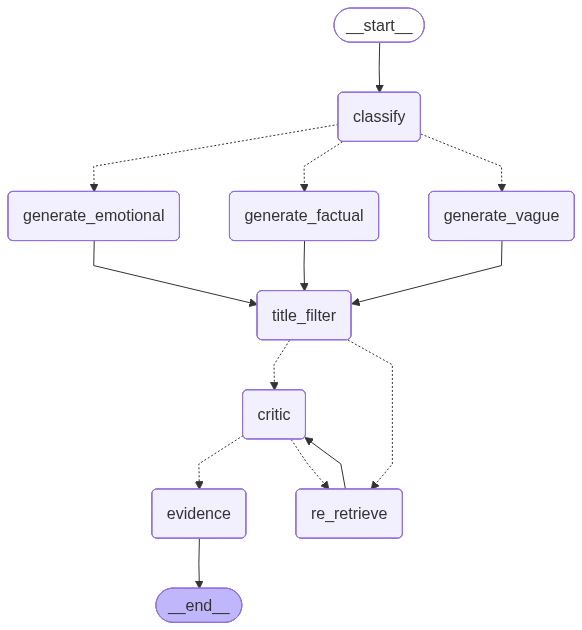

In [14]:
display(
    Image(
        orchestrator_graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

### 4d. Top-Level Runner

In [15]:
def run_orchestrator(query: str) -> OrchestratorResult:
    final_state = orchestrator_graph.invoke({
        "question":    query,
        "retry_count": 0
    })
    return OrchestratorResult(
        answer=final_state.get("answer", ""),
        question_type=QuestionType(final_state.get("question_type", "factual")),
        strategy=final_state.get("strategy", ""),
        evidence=final_state.get("evidence", []),
        critic_judgment=final_state.get("critic_judgment", {}),
    )

### 4e. Example

In [16]:
sample_query = "What is the occupation of Ilya and Shane in Heated Rivery?"
orc_result   = run_orchestrator(sample_query)
orc_result

OrchestratorResult(answer='Ilya Rozanov is a professional hockey player picked first by the Boston Raiders, while Shane Hollander is also a professional hockey player picked second by the Montreal Metros in the Major League Hockey (MLH) draft.', question_type=<QuestionType.FACTUAL: 'factual'>, strategy='rewrite_rerank', evidence=[{'title': 'Heated Rivalry', 'id': 't_301507_3', 'snippet': 'Ilya and Shane continue to hook up from 2014 to 2016. In 2015, the Metros win their first cup in sixteen years and defend their title in 2016'}, {'title': 'Heated Rivalry', 'id': 't_301507_5', 'snippet': "Kip and his friends watch on TV as Scott discusses his public coming out while accepting the MVP award. Shane drives Ilya to Shane's cottage, where both reveal neither has had sex with anyone else in the months since they were last together"}, {'title': 'Heated Rivalry', 'id': 't_301507_4', 'snippet': 'At dinner with Rose, Shane confirms her suspicions and admits he is gay, but they agree to remain f

In [17]:
missing_title_query = "What is the occupation of Ilya and Shane?"
orc_result   = run_orchestrator(missing_title_query)
orc_result

OrchestratorResult(answer='Ilya Rozanov is a professional hockey player in the Major League Hockey (MLH). Shane Hollander is also a professional hockey player, having played for the Montreal Metros. Both characters are involved in a romantic and sexual relationship throughout the narrative.', question_type=<QuestionType.FACTUAL: 'factual'>, strategy='rewrite_rerank', evidence=[{'title': 'Heated Rivalry', 'id': 't_301507_3', 'snippet': 'Ilya and Shane continue to hook up from 2014 to 2016. In 2015, the Metros win their first cup in sixteen years and defend their title in 2016'}, {'title': 'Heated Rivalry', 'id': 't_301507_1', 'snippet': "Shane and Ilya begin sexting over the course of two years, including before their game in fall 2013, after which they meet at Shane's apartment and have anal sex for the first time. During the 2014 Winter Olympics in Sochi, Ilya begins ignoring Shane's texts after his Russian hockey team performs poorly"}, {'title': 'Heated Rivalry', 'id': 't_301507_4',

In [18]:
not_exist_query = "the relationship between dhacha and alansb in pasknc?"
orc_result   = run_orchestrator(not_exist_query)
orc_result

OrchestratorResult(answer="I don't know.", question_type=<QuestionType.FACTUAL: 'factual'>, strategy='rewrite_rerank', evidence=[{'title': 'Love Design', 'id': 't_287376_1', 'snippet': 'After a confusing night at a Japanese bar, the relationship between Aokbab and Rin becomes even more awkward. Rin discovers that Aokbab’s architectural design connects to a painting she had fallen in love with three years ago in Kitakyushu'}, {'title': 'Aap Jaisa Koi', 'id': 'm_296_1', 'snippet': 'family connections, a marriage proposal is soon arranged between Shri and Madhu. Encouraged by Kusum, Shri travels to Kolkata to meet her'}, {'title': 'Brother', 'id': 'm_235_0', 'snippet': 'Karthik, a dropout law student, is the troublesome son of Kumarasamy and Saraswathi. His penchant for questioning injustices often lands him in controversy'}], critic_judgment={'supported': False, 'explanation': 'Failed to parse critic JSON; treating as unsupported.', 'revised_answer': "I don't know."})

In [19]:
sample_query2 = "What make Benny Scanlon heatbreak in Overcompensating??"
orc_result   = run_orchestrator(sample_query2)
orc_result

OrchestratorResult(answer='Benny Scanlon experiences heartbreak in "Overcompensating" when he misreads Miles\' readiness for a relationship, leading to a significant setback. His feelings for Miles create tension, especially as he navigates coming out and relationships. This culminates in disappointment when he realizes the timing is not right.', question_type=<QuestionType.EMOTIONAL: 'emotional'>, strategy='rewrite_only', evidence=[{'title': 'Overcompensating', 'id': 't_247619_1', 'snippet': "Feeling that he's lacking in college, Benny decides to have an impromptu dorm-room party in order to establish his friend group. Meanwhile, Carmen tries to score a fake ID."}, {'title': 'Overcompensating', 'id': 't_247619_2', 'snippet': "To avoid his feelings for Miles, Benny begins to spend extra time with Carmen. Carmen begins to struggle as the anniversary of her brother's death arrives"}, {'title': 'Overcompensating', 'id': 't_247619_5', 'snippet': 'After Benny comes out to Carmen, she decide

In [20]:
sample_query3 = "How do Milo Bradford and his wife respond to the kidnapping?"
orc_result   = run_orchestrator(sample_query3)
orc_result

OrchestratorResult(answer="Ellie Cain joins an anonymous group for parents of kidnapped children, seeking support and guidance. They are concerned about the implications of a package that suggests their child might not have been the only target. Additionally, something from Conrad Cain's past may have a connection to Leopold's kidnapping.", question_type=<QuestionType.EMOTIONAL: 'emotional'>, strategy='rewrite_only', evidence=[{'title': 'Kidnap', 'id': 't_237326_0', 'snippet': "The son of millionaire Conrad Cain and his wife Ellie, 15-year-old Leopold, is kidnapped on his way to school. The boy's bodyguard, Virgil, is left for dead at the scene"}, {'title': 'Kidnap', 'id': 't_237326_6', 'snippet': 'The kidnapping is made public by the media.'}, {'title': 'Kidnap', 'id': 't_237326_3', 'snippet': "The kidnappers target Leopold's bodyguard Virgil, once again, as he prepares for surgery. Conrad is questioned by the police regarding something from his past"}], critic_judgment={'supported': 

In [ ]:
records = []
queries = [sample_query, sample_query2, sample_query3, missing_title_query, not_exist_query]

for q in queries:
    orc_result = run_orchestrator(q)
    records.append({
        "query":          q,
        "answer":         orc_result.answer,
        "question_type":  orc_result.question_type.value,
        "strategy":       orc_result.strategy,
        "critic_supported": orc_result.critic_judgment.get("supported") if orc_result.critic_judgment else None,
        "critic_explanation": orc_result.critic_judgment.get("explanation") if orc_result.critic_judgment else None,
    })

df = pd.DataFrame(records)
df.to_csv("evaluation_report/based_agent_results.csv", index=False)
df

,query,answer,question_type,strategy,critic_supported,critic_explanation
0,What is the occupation of Ilya and Shane in He...,Ilya Rozanov is a hockey player drafted by the...,factual,rewrite_rerank,False,Failed to parse critic JSON; treating as unsup...
1,What make Benny Scanlon heatbreak in Overcompe...,Benny Scanlon navigates complex feelings in 'O...,emotional,rewrite_only,False,The original answer inaccurately implies that ...
2,How do Milo Bradford and his wife respond to t...,Conrad Cain and his wife Ellie are deeply affe...,emotional,rewrite_only,False,The original answer incorrectly mentions Milo ...
3,What is the occupation of Ilya and Shane?,Ilya and Shane are both hockey players in the ...,factual,rewrite_rerank,False,Failed to parse critic JSON; treating as unsup...
4,the relationship between dhacha and alansb in ...,The retrieved context does not provide informa...,factual,rewrite_rerank,False,Failed to parse critic JSON; treating as unsup...
